In [1]:
import pandas as pd
import numpy as np

Mean cosine similarity (gender vs. refusal): -0.1533


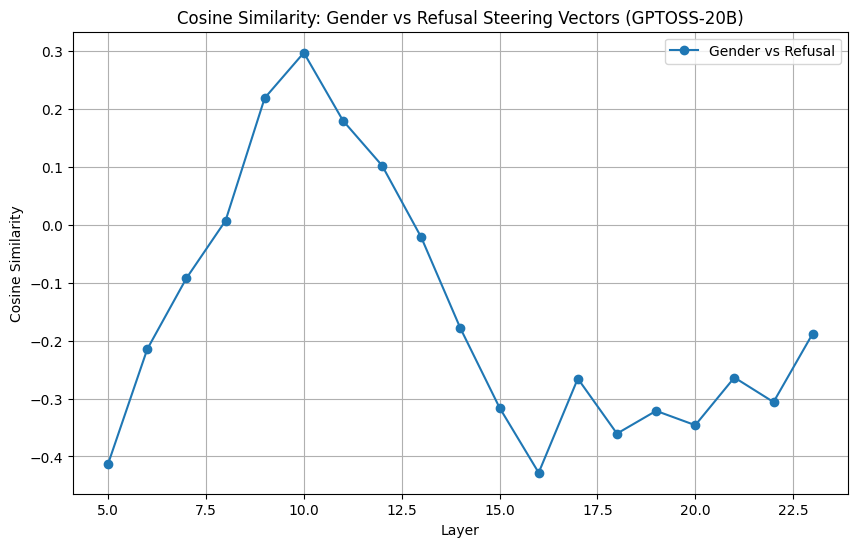

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Paths
base_dir = "/home/chakrabort/Documents/Gptoss"
gender_dir = f"{base_dir}/gender_rlhf_wrapper"
refusal_dir = f"{base_dir}/refusal_rlhf_wrapper"

layers = list(range(5,24))  # 0 to 31
cosine_similarities = []

for layer in layers:
    try:
        gender_vec = torch.load(f"{gender_dir}/vec_layer_{layer}.pt").float()
        refusal_vec = torch.load(f"{refusal_dir}/vec_layer_{layer}.pt").float()

        # Compute cosine similarity
        sim = F.cosine_similarity(gender_vec.unsqueeze(0), refusal_vec.unsqueeze(0))
        cosine_similarities.append(sim.item())
    except Exception as e:
        print(f"❌ Error loading layer {layer}: {e}")
        cosine_similarities.append(None)  # Append None for missing layers

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)
print(f"Mean cosine similarity (gender vs. refusal): {mean_similarity:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(layers, cosine_similarities, marker='o', label='Gender vs Refusal')
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Gender vs Refusal Steering Vectors (GPTOSS-20B)")
plt.grid(True)
plt.legend()
plt.show()


Mean cosine similarity (race vs. refusal): 0.0015


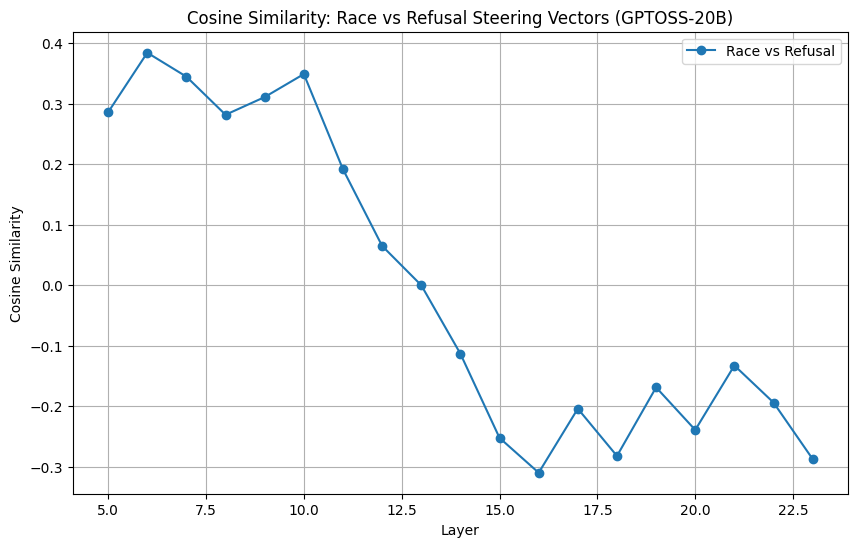

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Paths
base_dir = "/home/chakrabort/Documents/Gptoss"
race_dir = f"{base_dir}/race_rlhf_wrapper"
refusal_dir = f"{base_dir}/refusal_rlhf_wrapper"

layers = list(range(5,24))  # 0 to 31
cosine_similarities = []

for layer in layers:
    try:
        race_vec = torch.load(f"{race_dir}/vec_layer_{layer}.pt").float()
        refusal_vec = torch.load(f"{refusal_dir}/vec_layer_{layer}.pt").float()

        # Compute cosine similarity
        sim = F.cosine_similarity(race_vec.unsqueeze(0), refusal_vec.unsqueeze(0))
        cosine_similarities.append(sim.item())
    except Exception as e:
        print(f"❌ Error loading layer {layer}: {e}")
        cosine_similarities.append(None)  # Append None for missing layers

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)
print(f"Mean cosine similarity (race vs. refusal): {mean_similarity:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(layers, cosine_similarities, marker='o', label='Race vs Refusal')
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Race vs Refusal Steering Vectors (GPTOSS-20B)")
plt.grid(True)
plt.legend()
plt.show()


Mean cosine similarity (religion vs. refusal): -0.1310


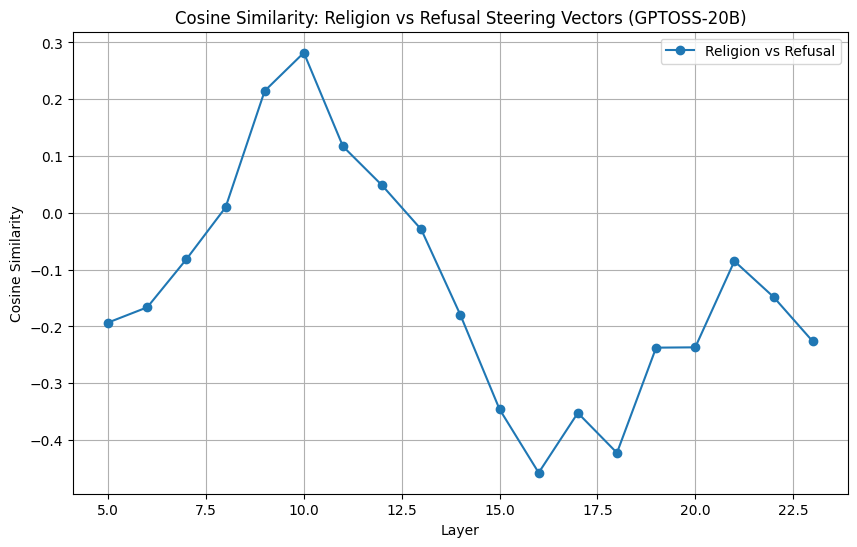

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Paths
base_dir = "/home/chakrabort/Documents/Gptoss"
religion_dir = f"{base_dir}/religion_rlhf_wrapper"
refusal_dir = f"{base_dir}/refusal_rlhf_wrapper"

layers = list(range(5,24))  # 0 to 31
cosine_similarities = []

for layer in layers:
    try:
        religion_vec = torch.load(f"{religion_dir}/vec_layer_{layer}.pt").float()
        refusal_vec = torch.load(f"{refusal_dir}/vec_layer_{layer}.pt").float()

        # Compute cosine similarity
        sim = F.cosine_similarity(religion_vec.unsqueeze(0), refusal_vec.unsqueeze(0))
        cosine_similarities.append(sim.item())
    except Exception as e:
        print(f"❌ Error loading layer {layer}: {e}")
        cosine_similarities.append(None)  # Append None for missing layers

mean_similarity = sum(cosine_similarities) / len(cosine_similarities)
print(f"Mean cosine similarity (religion vs. refusal): {mean_similarity:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(layers, cosine_similarities, marker='o', label='Religion vs Refusal')
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Religion vs Refusal Steering Vectors (GPTOSS-20B)")
plt.grid(True)
plt.legend()
plt.show()


Mean cosine similarity (Gender vs Race): 0.4612
Mean cosine similarity (Gender vs Religion): 0.5328
Mean cosine similarity (Race vs Religion): 0.5090


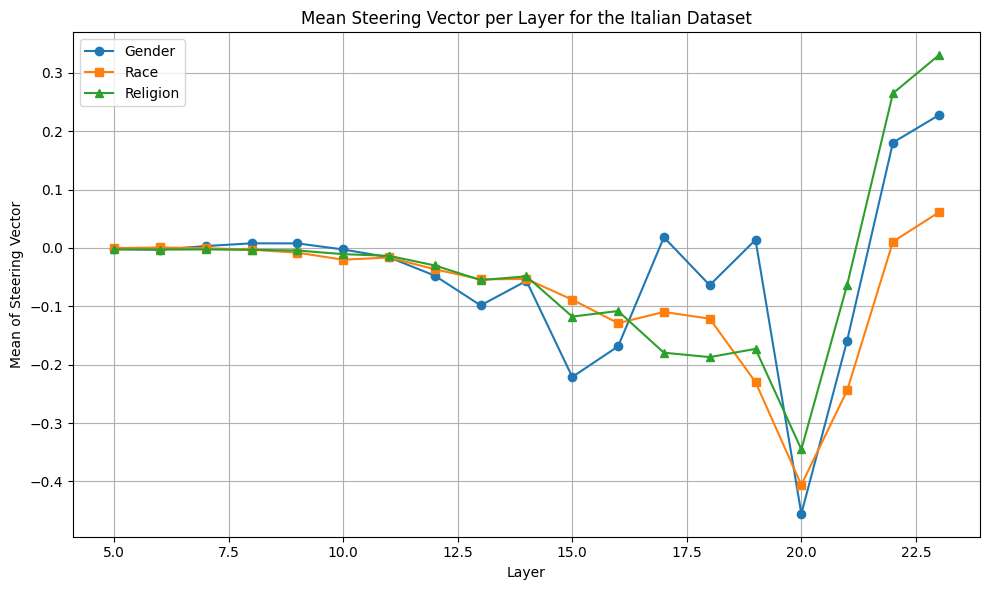

In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Directories for the three categories
gender_dir = "/home/chakrabort/Documents/Gptoss/gender_rlhf_wrapper"
race_dir = "/home/chakrabort/Documents/Gptoss/race_rlhf_wrapper"
religion_dir = "/home/chakrabort/Documents/Gptoss/religion_rlhf_wrapper"

layers = list(range(5, 24))

means_gender = []
means_race = []
means_religion = []

cos_gender_race = []
cos_gender_religion = []
cos_race_religion = []

for layer in layers:
    vec_gender = None
    vec_race = None
    vec_religion = None

    try:
        vec_gender = torch.load(f"{gender_dir}/vec_layer_{layer}.pt", map_location="cpu").float()
        means_gender.append(vec_gender.mean().item())
    except Exception as e:
        print(f"Gender layer {layer} skipped due to error: {e}")
        means_gender.append(None)

    try:
        vec_race = torch.load(f"{race_dir}/vec_layer_{layer}.pt", map_location="cpu").float()
        means_race.append(vec_race.mean().item())
    except Exception as e:
        print(f"Race layer {layer} skipped due to error: {e}")
        means_race.append(None)

    try:
        vec_religion = torch.load(f"{religion_dir}/vec_layer_{layer}.pt", map_location="cpu").float()
        means_religion.append(vec_religion.mean().item())
    except Exception as e:
        print(f"Religion layer {layer} skipped due to error: {e}")
        means_religion.append(None)

    if vec_gender is not None and vec_race is not None:
        cos_gender_race.append(
            F.cosine_similarity(vec_gender.unsqueeze(0), vec_race.unsqueeze(0)).item()
        )

    if vec_gender is not None and vec_religion is not None:
        cos_gender_religion.append(
            F.cosine_similarity(vec_gender.unsqueeze(0), vec_religion.unsqueeze(0)).item()
        )

    if vec_race is not None and vec_religion is not None:
        cos_race_religion.append(
            F.cosine_similarity(vec_race.unsqueeze(0), vec_religion.unsqueeze(0)).item()
        )

# Print mean cosine similarities across layers
if cos_gender_race:
    print(f"Mean cosine similarity (Gender vs Race): {sum(cos_gender_race) / len(cos_gender_race):.4f}")

if cos_gender_religion:
    print(f"Mean cosine similarity (Gender vs Religion): {sum(cos_gender_religion) / len(cos_gender_religion):.4f}")

if cos_race_religion:
    print(f"Mean cosine similarity (Race vs Religion): {sum(cos_race_religion) / len(cos_race_religion):.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(layers, means_gender, label="Gender", marker="o")
plt.plot(layers, means_race, label="Race", marker="s")
plt.plot(layers, means_religion, label="Religion", marker="^")

plt.title("Mean Steering Vector per Layer for the Italian Dataset")
plt.xlabel("Layer")
plt.ylabel("Mean of Steering Vector")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()